# 02 — Feature Engineering

## Purpose

This notebook takes the cleaned `mart_ml` dataset (see `01-EDA.ipynb` for the 
full data quality investigation) and builds the exact dataset used for Prophet 
training: applying the Tier 1 seller filter, dropping unused columns, 
validating feature coverage per series, and providing a reusable function to 
extract clean per-series data.

**Note:** Feature *selection* (testing whether `rating`, `reviews`, 
`day_of_week`, etc. are genuinely predictive) is deferred until ~60 days of 
history is reached (~June 27, 2026) — correlation tests on the current 
30-50 row series would be unreliable. This notebook covers only the 
structural work that doesn't depend on data volume.

---

## Tier 1 Modeling Population

**Definition:** A product/seller series qualifies for Tier 1 modeling if it has:
1. **Not** a cross-border import reseller (`Desertcart.ae`, `desertcart.co.za`, 
   `desertcart.com.sa`, `Ubuy`, `u-buy.co.nz`) — these include import duties 
   and cross-border markup, not representative of local retail price movement.
2. **31 or more daily observations** — enough history for a meaningful 
   train/test split and stable lag/rolling-average features.

**Result:** 42 product/seller series across 7 products, 1,897 rows total.

| Product | Tier 1 sellers |
|---|---|
| HP Spectre x360 | 8 |
| MacBook Air M3 | 8 |
| Samsung Galaxy A54 | 7 |
| Dell XPS 13 | 6 |
| Samsung Galaxy S24 | 5 |
| GoPro Hero 13 | 4 |
| iPhone 15 | 4 |
| **DJI Osmo Action** | **0 — excluded** |

**DJI Osmo Action excluded entirely.** Only 55 total rows remain after data 
cleaning (see EDA Section 5h) — confirmed this reflects genuinely limited 
current retail availability for the base model, largely superseded by 
"Osmo Action 5 Pro" in the market, not a filtering bug. Revisit if listing 
volume increases.

**Tier 2 (14–30 observations)** exists but is not used yet — these series 
will naturally cross into Tier 1 as the pipeline continues running daily. 
Re-check this threshold periodically (next checkpoint: ~July).

---

## Columns Dropped From the Feature Set

- `discount_pct`, `old_price` — 97%+ sparse at the source (see EDA Section 5b). 
  `is_on_sale` (fully populated, binary) is retained as the reliable sale 
  signal instead.

## Columns Retained, Pending Feature-Selection Testing

- `rating`, `reviews`, `rating_status` — plausible but unverified signals. 
  To be tested for correlation with price once data volume supports it.
- `day_of_week`, `day_of_month`, `week_of_year` — calendar features, 
  usefulness to be evaluated alongside Prophet's built-in seasonality once 
  more cycles of data exist.
- `variant_count` — diagnostic from the `mart_ml` aggregation logic (how many 
  same-day listings existed before the most-frequent-price selection was 
  applied). Potentially informative (more variants could correlate with 
  seller popularity/competition) but not yet tested.

## Deferred: Holiday Features

Considered adding a holiday indicator (e.g. Prophet's `add_country_holidays
('NZ')`) to help distinguish promotional pricing patterns. **Deferred** — 
current data window (Apr–Jun 2026) contains only one minor NZ holiday 
(King's Birthday) and none of the major electronics-pricing events 
(Black Friday, Cyber Monday, Christmas, Boxing Day). Revisit once the 
dataset extends into Nov/Dec 2026.

---

## Reusable Function

```python
def get_series(df, product_name, seller):
    """
    Return a clean Prophet-ready dataframe (ds, y) for one product/seller pair.
    Sorted by date, deduplicated, ready to pass to Prophet().fit().
    """
```

Used by the upcoming training notebook (`03_prophet_training.ipynb`) to pull 
each series individually for per-product/seller model fitting.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from utils.db import get_engine, load_mart_ml

engine = get_engine()
df = load_mart_ml(engine)
df['ds'] = pd.to_datetime(df['ds'])
df['category'] = df['category'].astype('category')

print(f"Raw mart_ml shape: {df.shape}")

Raw mart_ml shape: (4345, 22)


In [2]:
# Apply business logic exclusion: cross-border import resellers
import_resellers = ['Desertcart.ae', 'desertcart.co.za', 'desertcart.com.sa', 'Ubuy', 'u-buy.co.nz']
df = df[~df['seller'].isin(import_resellers)].copy()

In [3]:
# Apply minimum observation threshold: 31+ days (Tier 1)
series_counts = df.groupby(['product_name', 'seller']).size()
tier1_keys = series_counts[series_counts >= 31].index

In [4]:
df_tier1 = df.set_index(['product_name', 'seller']).loc[tier1_keys].reset_index()

print(f"After import-reseller exclusion + Tier 1 filter: {df_tier1.shape}")
print(f"\nSeries remaining per product:")
print(df_tier1.groupby('product_name')['seller'].nunique().sort_values(ascending=False))

After import-reseller exclusion + Tier 1 filter: (2300, 22)

Series remaining per product:
product_name
HP Spectre x360       9
MacBook Air M3        8
Samsung Galaxy A54    7
Samsung Galaxy S24    7
Dell XPS 13           6
GoPro Hero 13         4
iPhone 15             4
Name: seller, dtype: int64


## Drop the columns we already decided not to use

In [5]:
# Drop discount_pct / old_price per EDA decision - is_on_sale is the reliable signal
df_model = df_tier1.drop(columns=['discount_pct', 'old_price'])

print(f"Columns remaining: {df_model.columns.tolist()}")

Columns remaining: ['product_name', 'seller', 'product_id', 'store_id', 'category', 'ds', 'y', 'price_lag_1d', 'price_lag_7d', 'price_ma_7d', 'price_ma_14d', 'price_delta_1d', 'is_on_sale', 'rating', 'reviews', 'rating_status', 'variant_count', 'day_of_week', 'day_of_month', 'week_of_year']


## Check lag/rolling feature usability per series

In [6]:
# For each series, check what fraction of rows have valid lag/rolling features
def check_feature_coverage(group):
    return pd.Series({
        'total_rows': len(group),
        'valid_lag_1d': group['price_lag_1d'].notna().sum(),
        'valid_lag_7d': group['price_lag_7d'].notna().sum(),
        'valid_ma_14d': group['price_ma_14d'].notna().sum(),
    })

coverage = df_model.groupby(['product_name', 'seller']).apply(check_feature_coverage).reset_index()
coverage['lag_7d_pct'] = (coverage['valid_lag_7d'] / coverage['total_rows'] * 100).round(1)

coverage.sort_values('lag_7d_pct').head(10)

/var/folders/qw/mns0z74d3t1_nqjy7zgm7mkw0000gn/T/ipykernel_61048/899413439.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = df_model.groupby(['product_name', 'seller']).apply(check_feature_coverage).reset_index()


,product_name,seller,total_rows,valid_lag_1d,valid_lag_7d,valid_ma_14d,lag_7d_pct
35,Samsung Galaxy S24,Kogan.com NZ,32,31,25,32,78.1
13,HP Spectre x360,eBay - bestcomputerdeal,34,33,27,34,79.4
18,HP Spectre x360,eBay - zmh688,36,35,29,36,80.6
40,Samsung Galaxy S24,eBay - yywirelesss,36,35,29,36,80.6
2,Dell XPS 13,eBay - grassroots-computers,37,36,30,37,81.1
32,Samsung Galaxy A54,eBay - soundsolutions_worldwide,38,37,31,38,81.6
39,Samsung Galaxy S24,eBay - soundsolutions_worldwide,38,37,31,38,81.6
11,HP Spectre x360,TieDex,38,37,31,38,81.6
28,Samsung Galaxy A54,TechCrazy,39,38,32,39,82.1
31,Samsung Galaxy A54,eBay - panda_electronic_au,39,38,32,39,82.1


## Build the reusable get_series() helper

In [7]:
def get_series(df, product_name, seller):
    """
    Return a clean Prophet - ready dataframe (ds, y) for one product/seller pair.
    Sorted by date, no duplicates, ready to pass to Prophet.fit()
    """

    series = (
        df[(df['product_name'] == product_name) & (df['seller'] == seller)][['ds','y']]
            .sort_values('ds')
            .drop_duplicates(subset = 'ds')
            .reset_index(drop=True)
    )

    return series

# Quick test
test_series = get_series(df_model, 'MacBook Air M3', 'PB Tech')
print(test_series.shape)
test_series.head()

(63, 2)


,ds,y
0,2026-04-28,2499.0
1,2026-04-29,2499.0
2,2026-04-30,2499.0
3,2026-05-01,2499.0
4,2026-05-02,2499.0


In [8]:
# Final Tier 1 series reference table
tier1_summary = df_model.groupby(['product_name', 'seller']).agg(
    total_rows=('y', 'count'),
    date_min=('ds', 'min'),
    date_max=('ds', 'max'),
    price_mean=('y', 'mean'),
    price_std=('y', 'std')
).round(2).sort_values(['product_name', 'total_rows'], ascending=[True, False])

tier1_summary

total_rows   date_min  \
product_name       seller                                                   
Dell XPS 13        eBay                                     61 2026-04-28   
                   eBay - new.techies                       61 2026-04-28   
                   Microless.com                            57 2026-04-28   
                   eBay - toptechgears                      47 2026-04-29   
                   eBay - r3newtech                         44 2026-04-28   
                   eBay - grassroots-computers              37 2026-04-28   
GoPro Hero 13      UwCameraStore.com                        63 2026-04-28   
                   JB Hi-Fi                                 59 2026-04-28   
                   eBay - thepixelhub                       52 2026-04-28   
                   eBay                                     40 2026-04-28   
HP Spectre x360    PB Tech                                  63 2026-04-28   
                   eBay                                     63 2026-04-28   
                   eBay - entique_australia                 63 2026-04-28   
                   eBay - samuraiheike                      63 2026-04-28   
                   eBay - surpluserecycle                   63 2026-04-28   
                   eBay - oz.gadgets                        58 2026-04-28   
                   TieDex                                   38 2026-04-29   
                   eBay - zmh688                            36 2026-04-28   
                   eBay - bestcomputerdeal                  34 2026-04-28   
MacBook Air M3     Microless.com                            63 2026-04-28   
                   PB Tech                                  63 2026-04-28   
                   eBay                                     63 2026-04-28   
                   eBay - bq_shop01                         63 2026-04-28   
                   MightyApe.co.nz                          60 2026-04-28   
                   Auckland Airport                         49 2026-04-28   
                   Dick Smith NZ                            43 2026-04-28   
                   AliExpress                               39 2026-04-28   
Samsung Galaxy A54 eBay - kickmobiles-ltd                   63 2026-04-28   
                   eBay                                     62 2026-04-28   
                   AliExpress                               49 2026-04-28   
                   eBay - xwcellphone                       45 2026-04-28   
                   TechCrazy                                39 2026-04-30   
                   eBay - panda_electronic_au               39 2026-04-28   
                   eBay - soundsolutions_worldwide          38 2026-04-28   
Samsung Galaxy S24 eBay - kickmobiles-ltd                   63 2026-04-28   
                   BecexTech New Zealand                    58 2026-04-28   
                   eBay                                     54 2026-04-28   
                   Reebelo NZ                               50 2026-05-02   
                   eBay - soundsolutions_worldwide          38 2026-04-28   
                   eBay - yywirelesss                       36 2026-04-28   
                   Kogan.com NZ                             32 2026-04-28   
iPhone 15          JB Hi-Fi                                 52 2026-05-02   
                   Mobile City                              51 2026-04-28   
                   Reebelo NZ                               44 2026-05-15   
                   applefix.co.nz                           42 2026-04-28   

                                                     date_max  price_mean  \
product_name       seller                                                   
Dell XPS 13        eBay                            2026-06-30      646.01   
                   eBay - new.techies              2026-06-30     1194.77   
                   Microless.com                   2026-06-30     3035.62   
                   eBay - toptechgears         

In [9]:
print(f"Shape: {df_model.shape}")
print(f"\nSeries per product (Tier 1):")
print(df_tier1.groupby('product_name')['seller'].nunique().sort_values(ascending=False))

Shape: (2300, 20)

Series per product (Tier 1):
product_name
HP Spectre x360       9
MacBook Air M3        8
Samsung Galaxy A54    7
Samsung Galaxy S24    7
Dell XPS 13           6
GoPro Hero 13         4
iPhone 15             4
Name: seller, dtype: int64


### Feature Selection Tests

#### Test 1: Does `day_of_week` actually show price patterns?

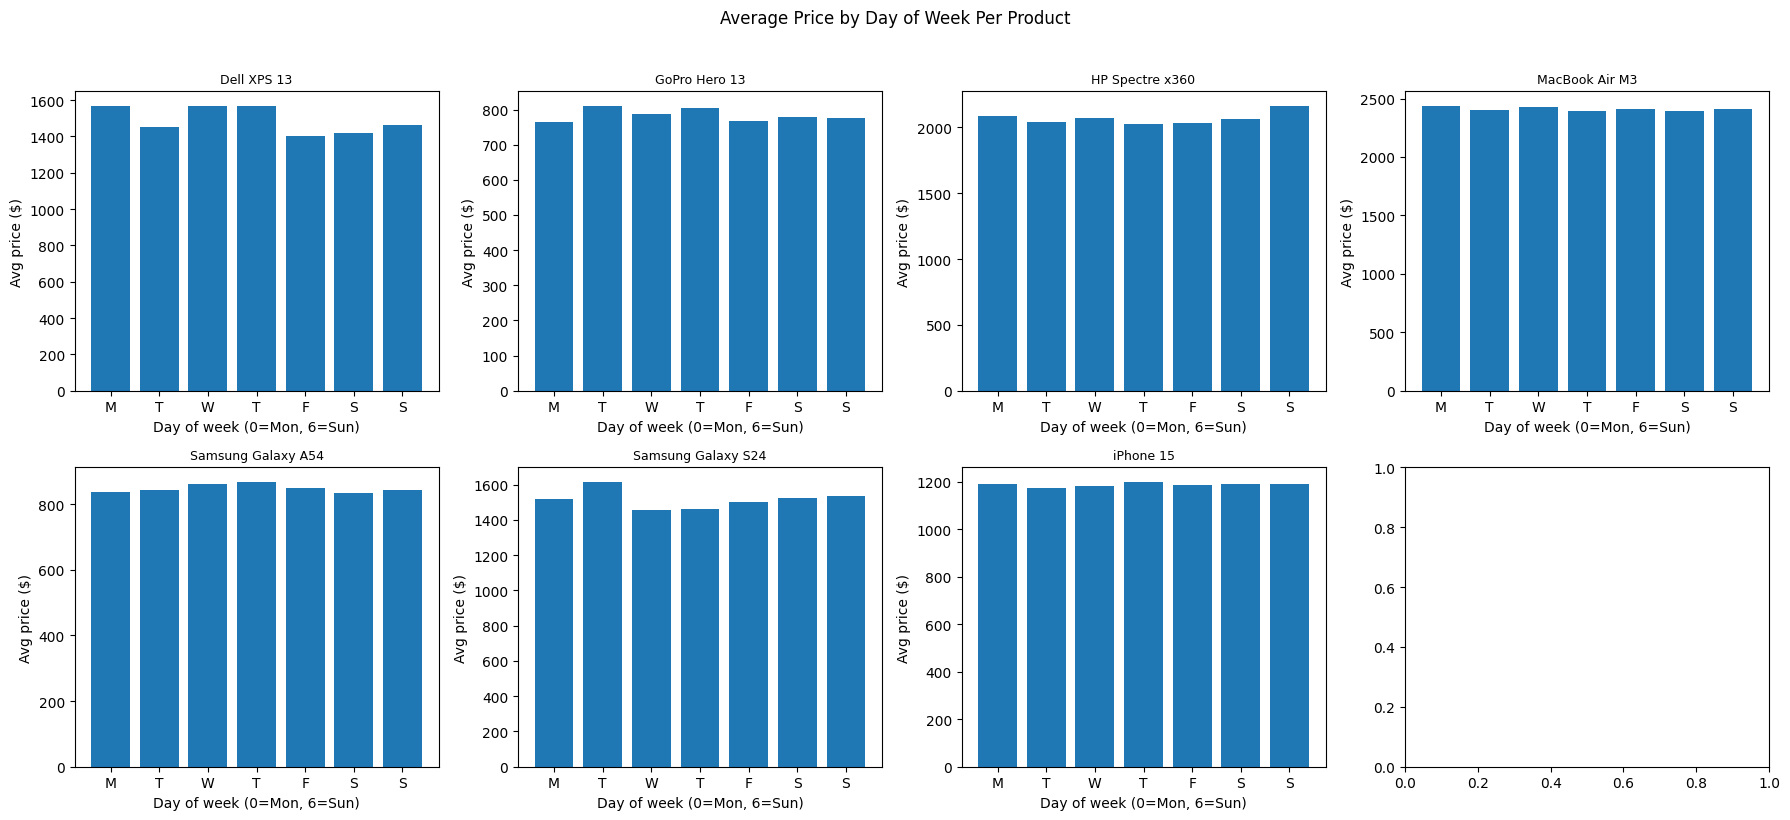

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(18,8))
axes = axes.flatten()

products = df_model['product_name'].unique()

for i, product in enumerate(products):
    subset = df_model[df_model['product_name'] == product]
    day_avg = subset.groupby('day_of_week')['y'].mean()

    ax = axes[i]
    ax.bar(day_avg.index, day_avg.values)
    ax.set_title(product, fontsize=9)
    ax.set_xlabel("Day of week (0=Mon, 6=Sun)")
    ax.set_ylabel("Avg price ($)")
    ax.set_xticks(range(7))
    ax.set_xticklabels(['M','T','W','T','F','S','S'])

plt.suptitle("Average Price by Day of Week Per Product", y = 1.02)
plt.tight_layout()
plt.show()

### Test 2: Does `rating/reviews` correlate with price?

In [12]:
# Pearson correlation of rating and reviews with price, per product 
corr_results = []

for product in df_model['product_name'].unique():
    subset = df_model[df_model['product_name'] == product].dropna(subset=['rating'])
    if len(subset) < 10:
        continue 
    corr_rating = subset['rating'].corr(subset['y']).round(3)
    corr_reviews = subset['reviews'].corr(subset['y']).round(3)
    corr_results.append({
        'product': product,
        'corr_rating_vs_price': corr_rating,
        'corr_reviews_vs_price': corr_reviews
    })

pd.DataFrame(corr_results).sort_values('corr_rating_vs_price', ascending = False)

,product,corr_rating_vs_price,corr_reviews_vs_price
6,iPhone 15,0.236,-0.234
3,MacBook Air M3,0.148,-0.114
4,Samsung Galaxy A54,0.078,-0.050
1,GoPro Hero 13,0.067,0.026
0,Dell XPS 13,-0.040,0.127
5,Samsung Galaxy S24,-0.242,0.151
2,HP Spectre x360,-0.656,0.410


#### Test 3: Does `is_on_sale` actually show a price difference?

In [14]:
# Compare mean price on sale vs not on sale, per product 
sale_effect = df_model.groupby(['product_name', 'is_on_sale'])['y'].mean().unstack()
sale_effect.columns = ['not_on_sale', 'on_sale']
sale_effect['pct_difference'] = ((sale_effect['on_sale'] - sale_effect['not_on_sale']) / sale_effect['not_on_sale'] * 100).round(2)
print("Price difference when on sale (%) per product:")
print(sale_effect.dropna())

Price difference when on sale (%) per product:
                    not_on_sale      on_sale  pct_difference
product_name                                                
GoPro Hero 13        792.466875   495.000000          -37.54
HP Spectre x360     2061.171967  3330.000000           61.56
MacBook Air M3      2411.287041  2437.825714            1.10
Samsung Galaxy S24  1526.757809   737.471429          -51.70
iPhone 15           1187.765193  1163.496250           -2.04


## Feature Selection Results

### Day of Week / Calendar Features
Average price by day of week shows negligible variation across all 7 products
(bars nearly flat in all panels). No meaningful day-of-week pricing pattern
exists in this dataset at the current data volume (60 days, <9 weekly cycles).

**Decision:** Drop `day_of_week`, `day_of_month`, `week_of_year` from Prophet
regressors. Prophet's built-in weekly seasonality (`weekly_seasonality=True`)
already covers this without needing explicit calendar columns.

### Rating / Reviews
Correlations with price are near-zero for most products (range: -0.04 to 0.148).
HP Spectre x360 shows an anomalous -0.656 — likely a confounding effect from
one specific seller's pricing/rating profile rather than a genuine signal.
Reviews correlations are similarly weak and inconsistent in direction.

**Decision:** Drop `rating`, `reviews`, `rating_status` from Prophet regressors.
Not enough signal to justify the complexity and potential noise they'd introduce.

### is_on_sale
Results are mixed and some values are implausible (HP Spectre showing +61.56%
price increase "on sale"). Sale events are rare (~2.8% of rows), limiting
statistical reliability. However, keeping it as a regressor costs nothing
and allows Prophet to use it if a pattern exists per-series.

**Decision:** Retain `is_on_sale` as the only extra Prophet regressor.
Drop it if it causes instability during training.

### Final Feature Set for Prophet
- `ds` — date (required)
- `y` — price (required)
- `is_on_sale` — binary sale flag (extra regressor, optional per series)

### Deferred
- Holiday features (Black Friday, Christmas) — revisit Nov/Dec 2026